In [12]:
#This cell loads the battery aging dataset from multiple folders, combining them into a single dictionary for further analysis. 
# Each cell's data is stored under its name as the key, allowing for easy access and manipulation in subsequent steps of the analysis. 
# The code also includes error handling to skip any files that cannot be loaded, ensuring that the process continues smoothly even if some files are problematic.
import scipy.io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_folder1 = 'data/battery_dataset/BatteryAgingARC_25_26_27_28_P1'
data_folder2 = 'data/battery_dataset/BatteryAgingARC_25-44'
data_folder3 = 'data/battery_dataset/BatteryAgingARC_45_46_47_48'
data_folder4 = 'data/battery_dataset/BatteryAgingARC_49_50_51_52'
data_folder5 = 'data/battery_dataset/BatteryAgingARC_53_54_55_56'
data_folder6 = 'data/battery_dataset/BatteryAgingARC-FY08Q4'

# Combine all data folders into a single list
data_folders = [data_folder1, data_folder2, data_folder3,
                data_folder4, data_folder5, data_folder6]
all_cells = {}

for data_folder in data_folders:
    for filename in os.listdir(data_folder):
        if filename.endswith('.mat'):
            cell_name = filename.replace('.mat', '')
            try:
                mat = scipy.io.loadmat(
                    os.path.join(data_folder, filename))
                all_cells[cell_name] = mat[cell_name][0][0]
                print(f'Loaded: {cell_name}')
            except Exception as e:
                print(f'Skipped {cell_name}: {e}')

print(f'\nTotal cells loaded: {len(all_cells)}')

Loaded: B0025
Loaded: B0026
Loaded: B0027
Loaded: B0028
Loaded: B0025
Loaded: B0026
Loaded: B0027
Loaded: B0028
Loaded: B0029
Loaded: B0030
Loaded: B0031
Loaded: B0032
Loaded: B0033
Loaded: B0034
Loaded: B0036
Loaded: B0038
Loaded: B0039
Loaded: B0040
Loaded: B0041
Loaded: B0042
Loaded: B0043
Loaded: B0044
Loaded: B0045
Loaded: B0046
Loaded: B0047
Loaded: B0048
Loaded: B0049
Loaded: B0050
Loaded: B0051
Loaded: B0052
Loaded: B0053
Loaded: B0054
Loaded: B0055
Loaded: B0056
Loaded: B0005
Loaded: B0006
Loaded: B0007
Loaded: B0018

Total cells loaded: 34


DCIR rows computed: (2451, 5)
    cell  cycle      dcir       soc  temperature
0  B0027     36  0.080479  1.819162    42.172551
1  B0029      1  0.111166  1.697507    43.406266
2  B0029      3  0.107639  1.844701    44.656755
3  B0029      5  0.107580  1.825438    44.703793
4  B0029      7  0.107405  1.815750    44.707477
5  B0029      9  0.107344  1.813299    44.694720
6  B0029     13  0.107633  1.815165    44.656321
7  B0029     15  0.107407  1.814332    44.687605
8  B0029     17  0.107664  1.801344    44.691531
9  B0029     19  0.107888  1.788156    44.678617


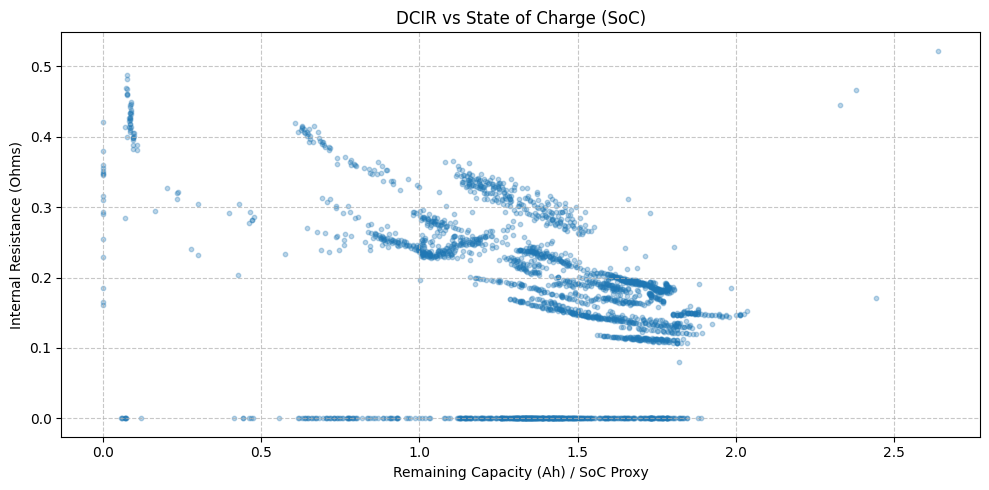

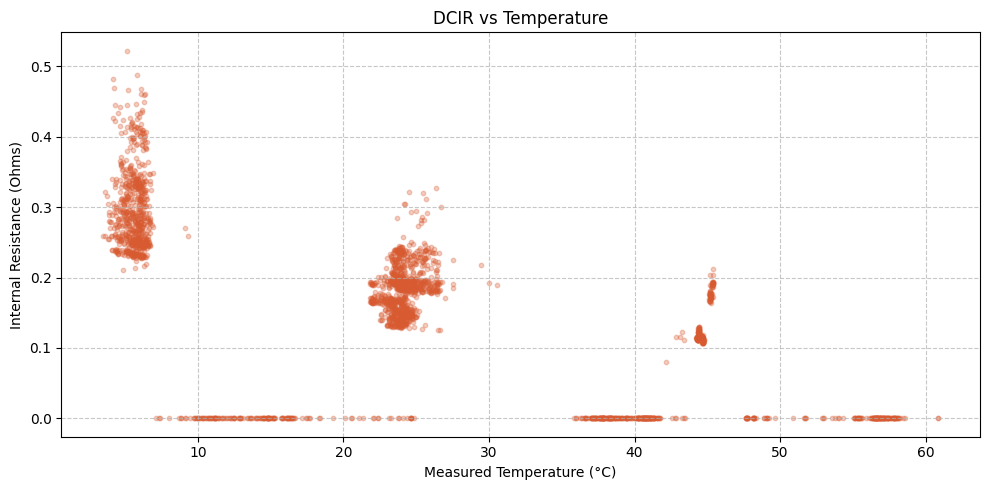

In [13]:
# ── Cell 2: Compute DCIR with SoC + temperature, then plot relationships ─────
dcir_rows = []

for cell_name, battery in all_cells.items():
    try:
        cycles = battery['cycle'][0]
    except Exception:
        continue

    for i, cycle in enumerate(cycles):
        try:
            if cycle['type'][0] != 'discharge':  # Filter only discharge cycles
                continue

            data = cycle['data'][0][0]

            # Time-series data during one discharge cycle
            V = data['Voltage_measured'].flatten()
            I = data['Current_measured'].flatten()
            soc = data['Capacity'].flatten()  # Capacity as SoC proxy
            temp = data['Temperature_measured'].flatten()

            # Need enough samples for pulse-window estimation
            if len(V) < 20 or len(I) < 20:
                continue

            # Step 1: detect strongest current transition (pulse proxy)
            dI_series = np.abs(np.diff(I))
            idx = int(np.argmax(dI_series))

            # Step 2: estimate DCIR over a short window
            window = 10
            if idx + window >= len(V) or idx + window >= len(I):
                continue

            V_before = V[idx]
            V_after = np.min(V[idx:idx + window])
            I_before = I[idx]
            I_after = I[idx + window]

            dV = abs(V_before - V_after)
            dI = abs(I_before - I_after)

            if dI > 0.05:
                dcir = dV / dI
                soc_val = float(soc[min(idx, len(soc) - 1)]) if len(soc) > 0 else np.nan
                temp_val = float(temp[min(idx, len(temp) - 1)]) if len(temp) > 0 else np.nan

                dcir_rows.append({
                    'cell': cell_name,
                    'cycle': i,
                    'dcir': round(float(dcir), 6),
                    'soc': soc_val,
                    'temperature': temp_val
                })
        except Exception:
            continue

# Build dataframe with fixed schema to avoid KeyError on empty results
dcir_df = pd.DataFrame(dcir_rows, columns=['cell', 'cycle', 'dcir', 'soc', 'temperature'])
print(f'DCIR rows computed: {dcir_df.shape}')
print(dcir_df.head(10))

plot_df = dcir_df.dropna(subset=['dcir', 'soc', 'temperature']).copy()
plot_df = plot_df[plot_df['dcir'] < 1.0]

if plot_df.empty:
    print('No valid DCIR rows for SoC/temperature plotting after filters.')
else:
    # Plot 1: DCIR vs SoC for all cells
    plt.figure(figsize=(10, 5))
    plt.scatter(plot_df['soc'], plot_df['dcir'], alpha=0.3, color='#1f77b4', s=10)
    plt.title('DCIR vs State of Charge (SoC)')
    plt.xlabel('Remaining Capacity (Ah) / SoC Proxy')
    plt.ylabel('Internal Resistance (Ohms)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot 2: DCIR vs Temperature for all cells
    plt.figure(figsize=(10, 5))
    plt.scatter(plot_df['temperature'], plot_df['dcir'], alpha=0.3, color='#D85A30', s=10)
    plt.title('DCIR vs Temperature')
    plt.xlabel('Measured Temperature (°C)')
    plt.ylabel('Internal Resistance (Ohms)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

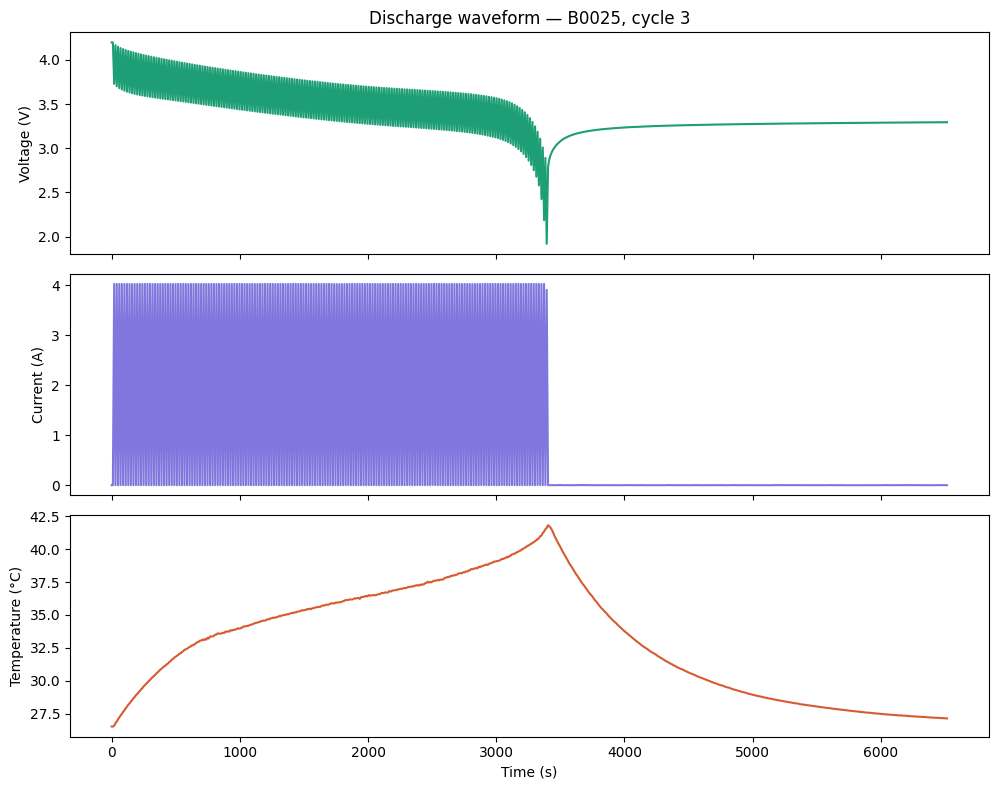

In [14]:
# ── Cell 4: Plot discharge waveform for one cell (V, I, T vs time) ───────────
# Pick first cell that has a discharge cycle with temperature data
plotted = False
for cell_name, battery in all_cells.items():
    if plotted:
        break
    try:
        cycles = battery['cycle'][0]
    except Exception:
        continue

    for i, cycle in enumerate(cycles):
        try:
            if cycle['type'][0] != 'discharge':
                continue
            data  = cycle['data'][0][0]
            V = data['Voltage_measured'].flatten()
            I = data['Current_measured'].flatten()
            T = data['Temperature_measured'].flatten()
            t = data['Time'].flatten()

            if len(V) < 10:
                continue

            fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

            axes[0].plot(t, V, color='#1D9E75', linewidth=1.5)
            axes[0].set_ylabel('Voltage (V)')
            axes[0].set_title(f'Discharge waveform — {cell_name}, cycle {i}')

            axes[1].plot(t, np.abs(I), color='#7F77DD', linewidth=1.5)
            axes[1].set_ylabel('Current (A)')

            axes[2].plot(t, T, color='#D85A30', linewidth=1.5)
            axes[2].set_ylabel('Temperature (°C)')
            axes[2].set_xlabel('Time (s)')

            plt.tight_layout()
            plt.savefig('data/discharge_waveform.png', dpi=150)
            plt.show()
            plotted = True
            break
        except Exception:
            continue


In [15]:
# ── Cell 5: DCIR summary statistics per cell ─────────────────────────────────
dcir_summary = dcir_df.groupby('cell')['dcir'].agg(
    first_cycle='first',
    last_cycle='last',
    mean='mean',
    pct_increase=lambda x: round((x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100, 1)
                 if x.iloc[0] > 0 else 0
).reset_index()

print('\nDCIR summary — resistance increase over lifetime:')
print(dcir_summary.sort_values('pct_increase', ascending=False).to_string())
# pct_increase shows how much internal resistance grew from first to last cycle
# Higher % = more degradation = matches your SoH findings from Day 1



DCIR summary — resistance increase over lifetime:
     cell  first_cycle  last_cycle      mean  pct_increase
17  B0043     0.185769    0.316775  0.169078          70.5
18  B0044     0.212842    0.339362  0.184543          59.4
23  B0049     0.258739    0.312364  0.244149          20.7
20  B0046     0.291876    0.338955  0.309043          16.1
19  B0045     0.363643    0.420116  0.232317          15.5
22  B0048     0.311699    0.338930  0.225172           8.7
27  B0053     0.279120    0.295288  0.279929           5.8
8   B0032     0.122900    0.129725  0.124060           5.6
11  B0036     0.196033    0.206576  0.190989           5.4
5   B0029     0.111166    0.115201  0.110537           3.6
6   B0030     0.115341    0.117904  0.114358           2.2
7   B0031     0.115002    0.115968  0.113132           0.8
14  B0040     0.000000    0.000000  0.087504           0.0
4   B0027     0.080479    0.080479  0.080479           0.0
2   B0007     0.000000    0.000000  0.120411           0.0
21  B

In [16]:
# ── Cell 6: Overlay DCIR trend with SoH from nasa_processed.csv ──────────────
# This connects your ECE signal analysis back to your ML dataset
nasa_df = pd.read_csv('nasa_processed.csv')

# Pick one cell that exists in both datasets
common_cells = set(dcir_df['cell'].unique()) & \
               set(nasa_df['battery_id'].astype(str).unique())
print(f'\nCells in both DCIR and NASA processed: {common_cells}')

if common_cells:
    cell = list(common_cells)[0]

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    # DCIR on left axis
    d = dcir_df[dcir_df['cell'] == cell].sort_values('cycle')
    ax1.plot(d['cycle'], d['dcir'],
             color='#D85A30', label='DCIR (Ω)', linewidth=1.5)
    ax1.set_ylabel('DCIR (Ω)', color='#D85A30')
    ax1.tick_params(axis='y', labelcolor='#D85A30')

    # SoH on right axis
    s = nasa_df[nasa_df['battery_id'].astype(str) == cell]\
        .sort_values('test_id')
    ax2.plot(s['test_id'], s['SoH'],
             color='#1D9E75', label='SoH (%)', linewidth=1.5,
             linestyle='--')
    ax2.set_ylabel('SoH (%)', color='#1D9E75')
    ax2.tick_params(axis='y', labelcolor='#1D9E75')

    ax1.set_xlabel('Cycle / Test ID')
    ax1.set_title(f'DCIR rises as SoH falls — cell {cell}\n'
                  f'(confirms internal resistance as early warning signal)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

    plt.tight_layout()
    plt.savefig('data/dcir_vs_soh.png', dpi=150)
    plt.show()
else:
    print('No overlapping cells — check battery_id format in nasa_processed.csv')




Cells in both DCIR and NASA processed: set()
No overlapping cells — check battery_id format in nasa_processed.csv


In [17]:
# ── Cell 7: Save DCIR dataset ─────────────────────────────────────────────────
dcir_df.to_csv('data/dcir_all_cells.csv', index=False)
print(f'Saved dcir_all_cells.csv — {dcir_df.shape[0]} rows, '
      f'{dcir_df["cell"].nunique()} cells')

Saved dcir_all_cells.csv — 2451 rows, 31 cells
